In [6]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
# 參數
ticker = "^TWII"   # TAIEX on Yahoo
start = "2019-09-29"
end_inclusive = "2025-10-03"

# yfinance 的 end 是「不含」當天，所以加 1 天
end_exclusive = (datetime.strptime(end_inclusive, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")

# 下載資料（日線）
df = yf.download(ticker, start=start, end=end_exclusive, interval="1d", auto_adjust=False)

# 整理欄位
df = df.reset_index()
df["Date"] = pd.to_datetime(df["Date"]).dt.date
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

# 輸出成 CSV
out_file = "HW3.csv"
df.to_csv(out_file, index=False, encoding="utf-8-sig")


[*********************100%***********************]  1 of 1 completed


In [8]:
# === 參數設定 ===
UP_PCT = 0.04     # 上界 +4%
DOWN_PCT = 0.02   # 下界 -2%
MAX_HOLD = 20     # 垂直障礙 20 天

# === 讀取資料 ===
df = pd.read_csv("HW3.csv")

# 確保數值欄位為 float
for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# === Triple Barrier ===
labels = []
high = df["High"].values
low = df["Low"].values
close = df["Close"].values
n = len(df)

for i in range(n):
    entry = close[i]
    if pd.isna(entry):
        labels.append(None)
        continue

    ub = entry * (1 + UP_PCT)
    lb = entry * (1 - DOWN_PCT)

    label = 0  # 預設垂直障礙
    start = i + 1
    end = min(i + 1 + MAX_HOLD, n)

    for j in range(start, end):
        if high[j] >= ub and low[j] <= lb:
            label = 0  # 同日同時觸發，視為無法判定
            break
        elif high[j] >= ub:
            label = 1  # 上界先觸發
            break
        elif low[j] <= lb:
            label = 2  # 下界先觸發
            break

    labels.append(label)

# === 存回原檔（只新增 TB_Label） ===
df["TB_Label"] = labels
df.to_csv("HW3.csv", index=False, encoding="utf-8-sig")

print(f"完成！已將 TB_Label 加入 HW3.csv，共 {len(df)} 筆。")

完成！已將 TB_Label 加入 HW3.csv，共 1464 筆。


In [9]:
import pandas as pd
import numpy as np

# 假設 df 已存在，且有 'Date' 與 'Close' 欄位
# 確保 close 為 float
close = df["Close"].astype(float)

# ========== 基礎工具 ==========
def sma(series: pd.Series, window: int) -> pd.Series:
    """簡單移動平均 (Simple Moving Average)"""
    return series.rolling(window=window, min_periods=window).mean()

def ema(series: pd.Series, span: int) -> pd.Series:
    """指數移動平均 (Exponential Moving Average)，等同 TA-Lib EMA"""
    return series.ewm(span=span, adjust=False).mean()

def rma(series: pd.Series, period: int) -> pd.Series:
    """
    Wilder's smoothing (又稱 RMA/SMMA)：
    RSI 需要用到。等同於 ewm(alpha=1/period, adjust=False)
    """
    alpha = 1.0 / period
    return series.ewm(alpha=alpha, adjust=False).mean()

# ========== BIAS ==========
def bias(series: pd.Series, window: int) -> pd.Series:
    """
    Bias ratio： (Close / SMA - 1) * 100
    與你原定義相同，但不使用 TA-Lib
    """
    m = sma(series, window)
    return (series / m - 1.0) * 100.0

# ========== RSI(14)（Wilder 定義，貼近 TA-Lib 計算）==========
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    計算 RSI（Wilder 版本，與 TA-Lib RSI 一致）
    步驟：
      1) 計算 diff
      2) 分別取 gains / losses
      3) 對 gains 與 losses 做 Wilder 平滑 (RMA)
      4) RS = avg_gain / avg_loss；RSI = 100 - 100 / (1 + RS)
    """
    delta = series.diff()

    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    avg_gain = rma(gain, period)
    avg_loss = rma(loss, period)

    rs = avg_gain / avg_loss
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

# ========== MACD(12,26,9)（貼近 TA-Lib 定義）==========
def macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    """
    TA-Lib 的 MACD：
      DIF = EMA(fast) - EMA(slow)
      SIGNAL = EMA(DIF, span=signal)
      HIST = DIF - SIGNAL
    """
    ema_fast = ema(series, fast)
    ema_slow = ema(series, slow)
    dif = ema_fast - ema_slow
    signal_line = ema(dif, signal)
    hist = dif - signal_line
    return dif, signal_line, hist

# ========== 計算欄位 ==========
df["BIAS_5"]  = bias(close, 5)
df["BIAS_10"] = bias(close, 10)
df["BIAS_20"] = bias(close, 20)
df["BIAS_60"] = bias(close, 60)

df["RSI_14"] = rsi(close, period=14)

macd_dif, macd_signal, macd_hist = macd(close, fast=12, slow=26, signal=9)
df["MACD_DIF"]    = macd_dif      # 快線 DIF
df["MACD_SIGNAL"] = macd_signal   # 慢線 Signal
df["MACD_HIST"]   = macd_hist     # 柱狀

# ========== 輸出（覆寫同一份 CSV，包含問題1+2+3）==========
df = df.sort_values("Date").reset_index(drop=True)
df.to_csv("HW3.csv", index=False, encoding="utf-8-sig")


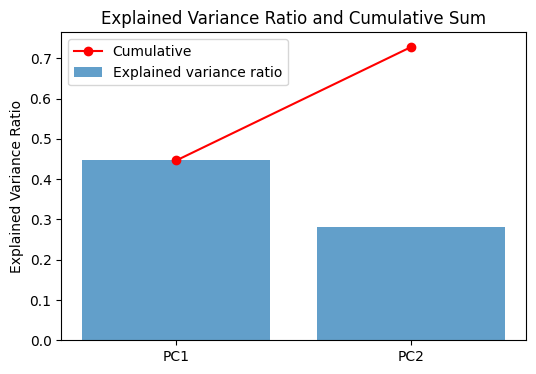

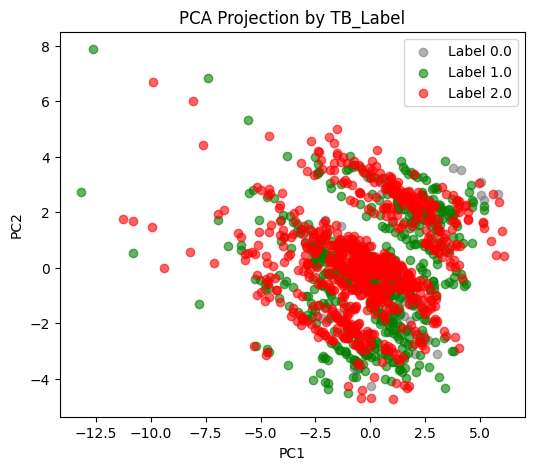

In [10]:
# === 讀取資料 ===
df = pd.read_csv("HW3.csv")

# 選取 Problem 1 + Problem 3 的特徵
features = ["Open", "High", "Low", "Close", "Volume",
            "BIAS_5", "BIAS_10", "BIAS_20", "BIAS_60",
            "RSI_14", "MACD_DIF", "MACD_SIGNAL", "MACD_HIST"]

X = df[features].dropna()
y = df.loc[X.index, "TB_Label"]

# === 標準化 ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === PCA 降維至2維 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 取解釋變異比例
explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

# === (A) 繪出解釋變異比例 ===
plt.figure(figsize=(6,4))
plt.bar(range(1, 3), explained, alpha=0.7, label="Explained variance ratio")
plt.plot(range(1, 3), cum_explained, marker="o", color="red", label="Cumulative")
plt.xticks([1, 2], ["PC1", "PC2"])
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.title("Explained Variance Ratio and Cumulative Sum")
plt.show()

# === (B) 繪出 PCA 平面分類圖 ===
plt.figure(figsize=(6,5))
colors = {0: "gray", 1: "green", 2: "red"}
for label in sorted(y.unique()):
    plt.scatter(X_pca[y==label, 0], X_pca[y==label, 1],
                label=f"Label {label}", alpha=0.6, c=colors[label])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA Projection by TB_Label")
plt.show()
